# Seed check: is the phase-2 multi-bump transient real oscillation or single-seed noise?

Follow-up per Jasper's message (relayed via Claude web chat, 2026-07-18), closing out the
last open item before the episodic-layer build: `two_layer_diagnostics.ipynb` found the
phase-2 misretrieval transient wasn't a simple decay — it rose to a peak (~0.95 at step 78),
dipped, then showed a secondary bump (~0.75-0.9) around step 180-200, before settling near 0.
Flagged as "possibly real competitive oscillation or single-seed noise, not distinguished."

**Task:** rerun the same setup (baseline params from the validated sweep: `w_char_max=10`,
`consolidation_rate=0.01`) across 10 different random seeds, overlay the phase-2
misretrieval-rate curves, and check whether the secondary bump's position is consistent
across seeds (real dynamics) or scattered (noise). Characterization only — no fix, no tuning.

Only need phases 1-2 (pattern 0 dominant, then pattern 1 dominant) to reproduce the phase-2
window, so the schedule here is truncated to `[0, 1]` instead of the full `[0, 1, 2, 0]` —
phase 2's dynamics only depend on phase 1 preceding it, not on what comes after.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [3]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0

def update_two_layer(w_fast, w_char, retrieval_weights):
    w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast * retrieval_weights
    headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
    w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * headroom
    return w_fast, w_char

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

def run_two_layer_experiment(phase_len, phase_patterns, seed=0, dominant_prob=0.7):
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"queried": queried_idx_history, "won": won_idx_history, "phase_bounds": phase_bounds}

def windowed_misretrieval_rate(queried, won, phase_start, phase_end, window=20):
    q = queried[phase_start:phase_end].numpy()
    w = won[phase_start:phase_end].numpy()
    misretrieval = ((w == 0) & (q != 0)).astype(float)
    kernel = np.ones(window) / window
    return np.convolve(misretrieval, kernel, mode="valid")

In [4]:
seeds = list(range(10))
phase2_rates = {}

for seed in seeds:
    run = run_two_layer_experiment(phase_len=400, phase_patterns=[0, 1], seed=seed)
    pb = run["phase_bounds"]
    phase2_rates[seed] = windowed_misretrieval_rate(run["queried"], run["won"], pb[1], pb[2], window=20)

print(f"Collected phase-2 misretrieval curves for {len(seeds)} seeds.")

Collected phase-2 misretrieval curves for 10 seeds.


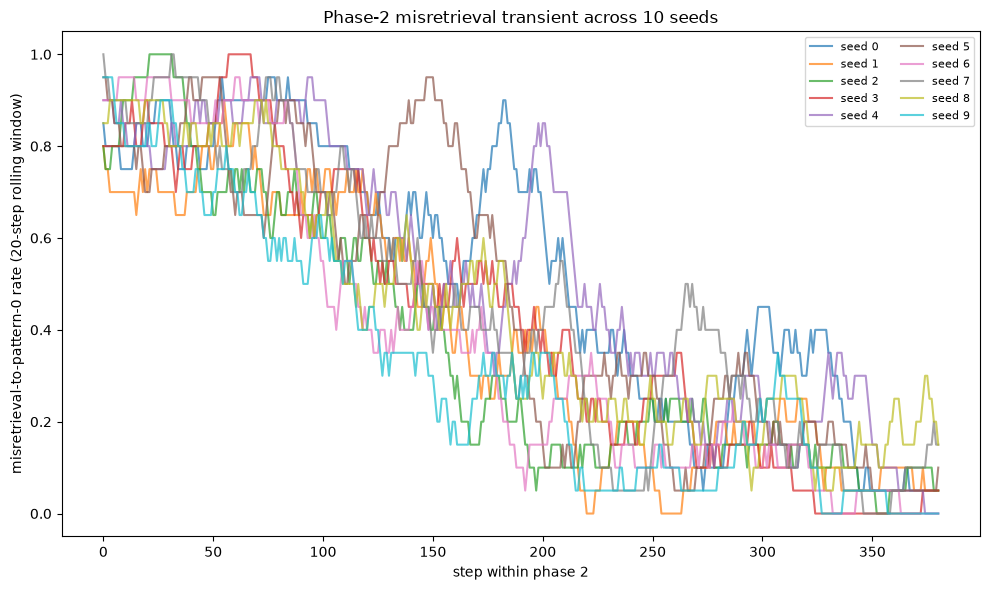

In [5]:
plt.figure(figsize=(10, 6))
for seed in seeds:
    plt.plot(phase2_rates[seed], alpha=0.7, label=f'seed {seed}')
plt.xlabel('step within phase 2')
plt.ylabel('misretrieval-to-pattern-0 rate (20-step rolling window)')
plt.title('Phase-2 misretrieval transient across 10 seeds')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('seed_check_overlay.png', dpi=100)
plt.show()

## Bump detection

For each seed, smooth lightly then find local maxima with `scipy.signal.find_peaks`
(prominence >= 0.15, so only "real" rises count, not step-to-step jitter). The first peak
near step 0 is just the curve starting near its max — what matters is whether there's a
**secondary** peak later in the phase (a genuine dip-then-rise), and if so, whether its
position is consistent across seeds.

In [6]:
bump_report = []
for seed in seeds:
    rate = phase2_rates[seed]
    smoothed = np.convolve(rate, np.ones(10) / 10, mode="valid")
    peaks, props = find_peaks(smoothed, prominence=0.15)
    # drop any peak in the first 20 steps -- that's just the initial high value, not a rebound
    real_peaks = [(p, smoothed[p]) for p in peaks if p > 20]
    bump_report.append((seed, len(real_peaks), real_peaks))
    peak_str = ", ".join(f"step {p} (val {v:.2f})" for p, v in real_peaks) if real_peaks else "none"
    print(f"seed {seed}: {len(real_peaks)} secondary bump(s) -> {peak_str}")

seed 0: 3 secondary bump(s) -> step 75 (val 0.92), step 177 (val 0.84), step 297 (val 0.42)
seed 1: 4 secondary bump(s) -> step 54 (val 0.84), step 234 (val 0.20), step 308 (val 0.23), step 314 (val 0.23)
seed 2: 1 secondary bump(s) -> step 21 (val 1.00)
seed 3: 2 secondary bump(s) -> step 57 (val 1.00), step 254 (val 0.32)
seed 4: 3 secondary bump(s) -> step 63 (val 0.92), step 195 (val 0.80), step 329 (val 0.32)
seed 5: 6 secondary bump(s) -> step 44 (val 0.94), step 79 (val 0.88), step 143 (val 0.92), step 228 (val 0.31), step 241 (val 0.31), step 287 (val 0.32)
seed 6: 1 secondary bump(s) -> step 214 (val 0.31)
seed 7: 3 secondary bump(s) -> step 73 (val 0.92), step 201 (val 0.48), step 264 (val 0.46)
seed 8: 1 secondary bump(s) -> step 307 (val 0.29)
seed 9: 2 secondary bump(s) -> step 195 (val 0.34), step 304 (val 0.28)


In [7]:
seeds_with_bump = [s for s, n, _ in bump_report if n > 0]
print(f"Seeds with at least one secondary bump: {seeds_with_bump} ({len(seeds_with_bump)}/{len(seeds)})")

if seeds_with_bump:
    first_bump_positions = [peaks[0][0] for s, n, peaks in bump_report if n > 0]
    print(f"First-secondary-bump positions: {first_bump_positions}")
    print(f"Mean position: {np.mean(first_bump_positions):.1f}, std: {np.std(first_bump_positions):.1f}")
    print(f"Range: {min(first_bump_positions)} - {max(first_bump_positions)}")

Seeds with at least one secondary bump: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10)
First-secondary-bump positions: [np.int64(75), np.int64(54), np.int64(21), np.int64(57), np.int64(63), np.int64(44), np.int64(214), np.int64(73), np.int64(307), np.int64(195)]
Mean position: 110.3, std: 89.4
Range: 21 - 307
